## **Imports and Setting Seeds**

In [1]:
# Standard library
import os
from pathlib import Path
import random

# Third-party libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms, datasets

# Ensure reproducibility with seeds
def set_seed(seed):
    # Seeds for main processes
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # For cuDNN determinism
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

## **Collect Paths and Labels**

In [2]:
# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device In Use: {str(device).upper()}")

# For retrieving image paths and labels
def get_img_paths_and_labels(base_dir):
    image_paths = np.array(list(Path(base_dir).glob("*/*.jpg")))
    labels = [p.parent.name for p in image_paths]
    return image_paths, labels
    
# Paths to train and test subdirectories
train_dir = "/kaggle/input/stanford-car-dataset-by-classes-folder/car_data/car_data/train"
test_dir = "/kaggle/input/stanford-car-dataset-by-classes-folder/car_data/car_data/test"

Device In Use: CUDA


### **Use a Validation Split**

In [3]:
# from sklearn.model_selection import train_test_split as tts

# # Collect training and test paths and labels
# orig_train_paths, orig_train_labels = get_img_paths_and_labels(train_dir)
# test_paths, test_labels = get_img_paths_and_labels(test_dir)

# # Split 10% of training data for validation
# split = tts(orig_train_paths, 
#             orig_train_labels, 
#             test_size=0.1, 
#             shuffle=True, 
#             stratify=orig_train_labels)

# train_paths, val_paths, train_labels, val_labels = split

# # Compute and print subset sizes
# print(f"Train Set Size: {len(train_paths)}")
# print(f"Validation Set Size: {len(val_paths)}")
# print(f"Test Set Size: {len(test_paths)}")

### **Use the Entire Training Segment**

In [4]:
from sklearn.model_selection import train_test_split as tts

# Collect training and test paths and labels
train_paths, train_labels = get_img_paths_and_labels(train_dir)
test_paths, test_labels = get_img_paths_and_labels(test_dir)

# Compute and print subset sizes
print(f"Train Set Size: {len(train_paths)}")
print(f"Test Set Size: {len(test_paths)}")

# Retrieve label names from official cars_meta.mat file
# /stanford-car-dataset-by-classes-folder/names.csv can also be used
from scipy.io import loadmat
cars_meta = loadmat("/kaggle/input/datasets/reubenjosephisidoro/cars-meta/cars_meta.mat")
class_names = [cls[0] for cls in cars_meta["class_names"][0]] 
print(f"Number of classes: {len(class_names)}")

# Map labels to class IDs in the correct order
LABELS_TO_IDS = {}
for idx, name in enumerate(class_names):
    # print(f"{name}: {idx+1}")
    # Keep this at 0-indexed for PyTorch compatibility
    LABELS_TO_IDS[name] = idx

# Correct slight mismatch for class id 173 (actual 174)
# to reflect the folder name provided and avoid errors later
LABELS_TO_IDS["Ram C-V Cargo Van Minivan 2012"] = LABELS_TO_IDS.pop("Ram C/V Cargo Van Minivan 2012")

Train Set Size: 8144
Test Set Size: 8041
Number of classes: 196


## **See Image Size Distribution**

In [5]:
from collections import Counter

# See image sizes
sizes = []
for img_path in train_paths:
    with Image.open(img_path) as img:
        channels = len(img.getbands())
        sizes.append(img.size + (channels,))  

print("((width, height, channels), count)")
Counter(sizes).most_common(7)

((width, height, channels), count)


[((640, 480, 3), 988),
 ((1024, 768, 3), 469),
 ((259, 194, 3), 392),
 ((480, 360, 3), 199),
 ((300, 225, 3), 189),
 ((1600, 1200, 3), 138),
 ((800, 600, 3), 135)]

## **Look at Actual Samples**

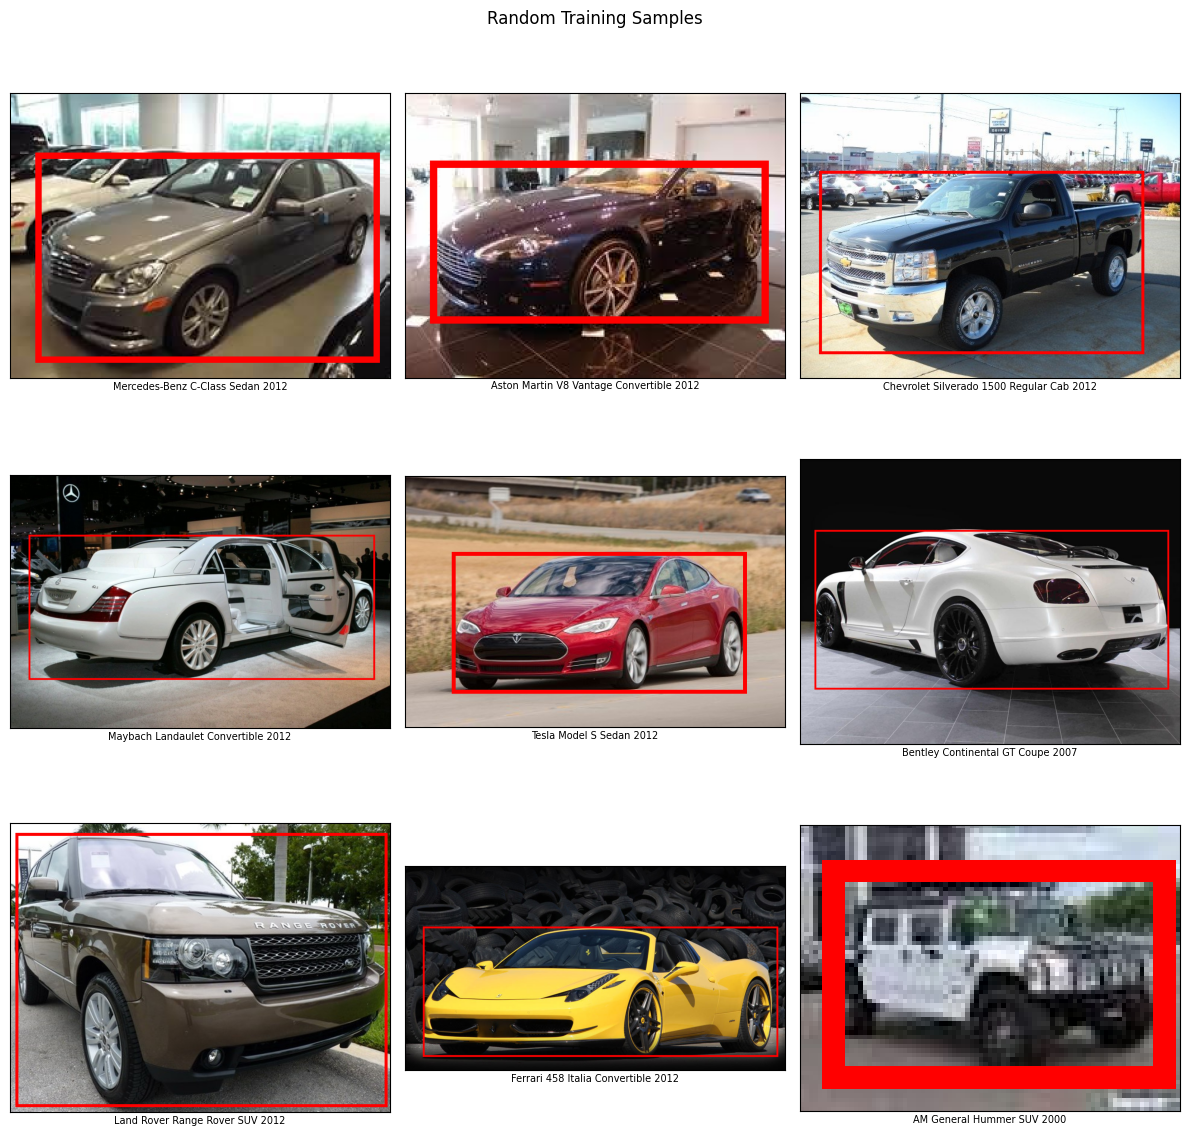

In [6]:
from torchvision.transforms import functional as F
from torchvision.utils import draw_bounding_boxes as dbb


def show_random_images(paths, title, n_row=3, n_col=3, transform=None, annotations=None): 
    """Reusable function for displaying random images with boxes."""
    
    fig1, axs1 = plt.subplots(n_row, n_col, figsize=(12, 12))
    rand_imgs = np.random.choice(paths, n_row*n_col, replace=False)
    for idx, ax in enumerate(axs1.flat):
        path = rand_imgs[idx]
        img = Image.open(path).convert("RGB")
        
        if transform: 
            img = transform(img)
            img = img.permute(1, 2, 0).numpy()        
            
        if annotations:
            col_names = ["name", "x1", "y1", "x2", "y2", "cls_id"]
            anno_df = pd.read_csv(annotations, header=None, names=col_names)
            sample = anno_df.loc[anno_df["name"] == path.name]
            x1, y1 = sample["x1"].iloc[0], sample["y1"].iloc[0]
            x2, y2 = sample["x2"].iloc[0], sample["y2"].iloc[0]
            cls_id = sample["cls_id"]
            img = F.pil_to_tensor(img)  # uint8 at [0,255]
            box = torch.tensor([[x1,y1,x2,y2]]).to(dtype=torch.float32)
            label = [path.parent.name]
            img = dbb(img, box, None, "red", width=5).permute(1,2,0)

        ax.imshow(img)
        ax.set_xlabel(path.parent.name, fontsize=7, labelpad=2)
        ax.set_xticks([])
        ax.set_yticks([])
    fig1.suptitle(title)
    plt.tight_layout()
    plt.show()

# See random training images
anno_train_path = "/kaggle/input/stanford-car-dataset-by-classes-folder/anno_train.csv"
show_random_images(train_paths, "Random Training Samples", 3, 3, None, anno_train_path)

## **Check for Class Imbalance**

To see if there are class imbalances in the dataset, we can perform the following analyses:

- Directly see the class distribution with a bar chart 
- Compute statistical metrics (e.g., Imbalance Ratio) to quantify the extent of imbalance

In [7]:
from plotly import express as px

# Helper function for counting class frequency
def label_counter(labels):
    label_counter = Counter(labels)
    key = lambda x:x[1]
    sorted_count = sorted(label_counter.items(), key=key, reverse=True)
    sorted_count_dict = dict(sorted_count)
    return sorted_count_dict

train_label_counts = label_counter(train_labels)

# Create interactive bar chart
fig2 = px.bar(x=train_label_counts.keys(),
             y=train_label_counts.values(),
             title="Class Distribution (Train Set)",
             labels={"x":"Car Model Bin", "y":"Number of Images"})
fig2.update_layout(xaxis=dict(showticklabels=False), height=600,)
fig2.show(renderer="iframe")

**Takeways:**

- The drop from the highest bar (slightly above 50) to the next (just below 40) is high, but afterward, we see a gradual decline of succeeding bars.
- The range of counts is relatively tight with one outlier on the left, so imbalance likely won’t be a problem in training.

In [8]:
# Helper func for computing Imbalance Ratio
def comp_imb_ratio(labels):
    label_counts = label_counter(labels)
    counts_arr = np.array(list(label_counts.values()))
    max_label, min_label = counts_arr.max(), counts_arr.min()
    imb_ratio = max_label / min_label
    return imb_ratio

# Helper func for computing gini coefficient
def comp_gini_coef(labels):
    label_counts = label_counter(labels)
    counts_arr = np.array(list(label_counts.values()))
    numerator = np.abs(np.subtract.outer(counts_arr, counts_arr)).sum()
    denominator = (2*len(counts_arr) * counts_arr.sum())
    gini_coef = numerator / denominator
    return gini_coef

# Compute train label IR and GC 
train_imb_ratio = comp_imb_ratio(train_labels)
train_gini_coef = comp_gini_coef(train_labels)
print(f"Train Subset IR: {train_imb_ratio:.2f}")
print(f"Train Subset GC: {train_gini_coef:.4f}", "\n")

Train Subset IR: 2.83
Train Subset GC: 0.0522 



**Takeaways:**

- No severe skew in the train set. The largest class has approx. 2.84x more samples than the smallest, indicating a light imbalance.
- GC for the train set labels is approx. 0.05 which is close to 0, which tells us the class distribution is fairly even.

## **Set Up an Augmentation Pipeline**

We create a `transforms` pipeline to preprocess and augment the dataset. Hopefully, we can introduce variations in training samples that will generalize well to the test segment.  

In [9]:
from PIL import ImageOps

# For resizing the image's longest side to a fixed size
# Later, shorter side will be padded
def resize_longest_side(image, size):
    W, H = image.size
    if W >= H:
        new_W, new_H = size, int(H * size / W)
    else:
        new_W, new_H = int(W * size / H), size
    return image.resize((new_W, new_H), Image.LANCZOS)

# Pad the shorter side after resizing
# This allows us to adhere to a fixed size without
# losing the original aspect ratio
def pad_to_square(image):
    W, H = image.size
    longest = max(W, H)
    pad_w = max(0, longest-W)
    pad_h = max(0, longest-H)
    l,t,r,b = pad_w//2, pad_h//2, pad_w - pad_w//2, pad_h - pad_h//2 
    return ImageOps.expand(image, border=(l,t,r,b), fill=0)

# Photometric augmentations go first then geometric ones
def get_transforms(train=True):
    augments = [ 
        transforms.Lambda(lambda image: resize_longest_side(image, 448)),
        transforms.Lambda(lambda image: pad_to_square(image))]

    if train:
        augments = ([transforms.ColorJitter(brightness=0.2, contrast=0.2)]
        + augments +[transforms.RandomHorizontalFlip()])
        
    augments += [transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])]

    return transforms.Compose(augments)

## **Define and Instantiate `Dataset` Objects**

We define a custom `Dataset` as a getter that also implements `len()` for `DataLoader`.

Our dataset class does the following:

- Store image file paths and string labels
- Map string labels to int indices
- Reverse-map indices to string labels
- Apply an augmentation pipeline 

***Note:*** We could have also relied on `ImageFolder` since the directory provided here is organized in a way it accepts.

In [10]:
class CarImageDataset(Dataset):
    def __init__(self, paths, str_labels, lbl_id_map, transform=None):
        self.paths = paths
        self.str_labels = str_labels
        self.transform = transform
        
        self.cls_to_id = lbl_id_map
        self.id_to_cls = {i:c for c,i in self.cls_to_id.items()}
        self.cls_ids = [self.cls_to_id[l] for l in self.str_labels]        

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        label_str = self.str_labels[idx]
        label_id = self.cls_ids[idx]
        if self.transform:
            image = self.transform(image)
        return image, label_id, label_str

train_data = CarImageDataset(train_paths, train_labels, LABELS_TO_IDS, get_transforms(train=True))
test_data = CarImageDataset(test_paths, test_labels, LABELS_TO_IDS, get_transforms(train=False))
# val_data = CarImageDataset(val_paths, val_labels, transform=get_transforms(train=False))

**Why We Did Not Use a Validation Holdout:**

- For this experiment, we intend to get the best performance possible on the test set, training on as much samples as we can.
- The approach will be to train on the full allocated training samples. 
- The training run will not use a validation holdout. Instead, the test set will be used directly to evaluate.
- Having no validation holdout should not be an okay practice in general

### **Wrap the `Dataset`s in `DataLoader`**

- Shuffle data when batching
- Use a batch size of 32 samples
- Use 2 workers for parallel data loading
- Set `pin_memory=True`

In [11]:
# Since we need to ensure DataLoader workers are deterministic as well
# This way, we ensure that results are actually identical across runs
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


g = torch.Generator()
g.manual_seed(42)


train_loader = DataLoader(
    dataset=train_data,
    batch_size=32,     
    shuffle=True,      
    num_workers=2,
    pin_memory=True,
    generator=g,
    worker_init_fn=seed_worker)

val_loader = DataLoader(
    test_data, 
    batch_size=32, 
    shuffle=False, 
    num_workers=2,
    pin_memory=True,
    generator=g,
    worker_init_fn=seed_worker)

## **Define Functions for Model Evaluation and Training**

- `eval_model` runs a single forward pass  to evaluate model performance.
- `train_epoch` executes one training epoch, updating parameters per batch.
- `train_model` uses both helper functions to manage the full tuning across epochs.
- `plot_loss_acc` plots the training run's loss and accuracy history

In [12]:
import time
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# For model evaluation or inference
def evaluate_model(model, loader, criterion, add_metrics=False):
    model.eval()
    running_loss = 0
    num_correct = 0
    total = 0
    all_labels, all_preds = [], []
    start = time.time()
    
    with torch.no_grad():  
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            num_correct += (predicted == labels).sum().item()
            total += labels.size(0)     
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    eval_metrics = running_loss/total, num_correct/total
    
    if add_metrics:
        prc = precision_score(all_labels, all_preds, average="weighted")
        rec = recall_score(all_labels, all_preds, average="weighted")
        f1 = f1_score(all_labels, all_preds, average="weighted")
        elapsed = time.strftime("%H:%M:%S", time.gmtime(time.time()-start))
        eval_metrics = eval_metrics + (prc,rec,f1,elapsed,all_labels,all_preds) 
    return eval_metrics


# For executing one training epoch
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    num_correct = 0.0
    total = 0.0
    start = time.time()
    
    for images, labels, _ in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)  # Outputs raw logits (n, 196)
        loss = criterion(outputs, labels)  # Single scalar tensor loss for the batch
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        num_correct += (predicted == labels).sum().item()
        total += labels.size(0)

    elapsed = time.time() - start
    epoch_metrics = running_loss/total, num_correct/total, elapsed
    return epoch_metrics  # loss, accuracy, total epoch time


# For full model tuning
def train_model(epochs, model, train_loader, val_loader, criterion, optimizer, stage):
    best_val_acc = 0.0
    early_stop = 5
    patience_ctr = 0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    avg_epoch_time = 0.0
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        train_loss, train_acc, epoch_time = train_epoch(model, train_loader, criterion, optimizer)
        train_losses.append(train_loss) 
        train_accs.append(train_acc)
        avg_epoch_time += epoch_time
        print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)
        val_losses.append(val_loss) 
        val_accs.append(val_acc)
        print(f"  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
        scheduler.step()
        if val_acc > best_val_acc:
            patience_ctr = 0
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"stage{stage}-best_params.pth")
            print(f"  ⚡ Most Accurate Model Saved")
        else:
            patience_ctr += 1
            if patience_ctr == early_stop: 
                print("  ☢️ Early Stopping Triggered\n")
                break
                
    avg_epoch_time = avg_epoch_time/epoch+1
    avg_epoch_time = time.strftime("%H:%M:%S", time.gmtime(avg_epoch_time))
    print(f"⌛ Avg. Epoch Time: {avg_epoch_time}")
    return train_losses, train_accs, val_losses, val_accs


# Plot loss and accuracy history
def plot_loss_acc(train_losses, train_accs, val_losses, val_accs):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].plot(train_losses, label="Train Loss")
    axs[0].plot(val_losses, label="Validation Loss")
    axs[0].set_title("Loss")
    axs[0].legend()
    axs[1].plot(train_accs, label="Train Acc")
    axs[1].plot(val_accs, label="Validation Acc")
    axs[1].set_title("Accuracy")
    axs[1].legend()
    plt.suptitle("Tuning History", fontsize=12)
    plt.tight_layout()
    plt.show()

## **Initial Tuning Strategy: Progressive Unfreezing**

The idea is to **progressively unfreeze layers in stages**, allowing low-level features to remain stable while later, high-level features adapt to the new dataset.  

- *Stage 1:* Train only the classifier head and deep layers
- *Stage 2:* Unfreeze mid-level layers
- *Stage 3:* Unfreeze the entire ResNet50 backbone  

This staged unfreezing aims to stabilize training by preserving the low-level features that are already learned by the pretrained backbone rather than having the weights update too much early in training that learned features in upstream layers are disrupted (see catastrophic forgetting). At the same time, it allows task-specific layers (the `fc` and `layer4`) to adapt first to the new data. Below we'll see how this goes.

**Note:** We define a `prog_unfreeze` function, which we call per stage (stages 1, 2, OR 3) instead of calling it once to facilitate the 3-stage unfreezing. This is because for our use case, we might want see and inspect results between stages and manually adjust hyperparameters. 

In [13]:
# Function for facilitating progressive unfreezing
def prog_unfreeze(model, train_loader, val_loader, n_epochs, 
                  optimizer, criterion, scheduler, stage=0):

    # Take into account if the model was wrapped in DataParallel or not
    resnet_backb = model.module if isinstance(model, nn.DataParallel) else model        

    if stage == 1:
        # Freeze all except layer3, layer4, and fc
        for name, param in resnet_backb.named_parameters():
            param.requires_grad = any(x in name for x in ["layer3", "layer4", "fc"])

    elif stage == 2:
        # Unfreeze layer2
        for param in resnet_backb.layer2.parameters(): 
            param.requires_grad = True

    else:
        # Unfreeze layer1
        for param in resnet_backb.layer1.parameters():
            param.requires_grad = True

        # Unfreeze conv1 of the stem block
        for param in resnet_backb.conv1.parameters():
            param.requires_grad = True

        # Unfreeze bn1 of stem
        for param in resnet_backb.bn1.parameters():
            param.requires_grad = True

    # Proceed with tuning
    tuning_metrics = train_model(n_epochs, model, train_loader, 
                                 val_loader, criterion, 
                                 optimizer, stage)
    
    # Display performance when the tuning run concludes
    train_losses, train_accs, val_losses, val_accs = tuning_metrics 
    plot_loss_acc(train_losses, train_accs, val_losses, val_accs)

    return tuning_metrics

### **Unfreeze ResNet50's Deep Layers (Stage 1)**

- Load torch's native pretrained ResNet50 
- Freeze all layers except deep layers (`layer3` and `layer4`)
- Replace the final classification layer to fit the 196-class dataset

We initialize the ff. configs/hyperparameters:

- Criterion/Loss Function: `CrossEntropyLoss`
- Optimizer: `SGD w. momentum` w/ `weight_decay=1e-4`
- Starting LR: `0.01`
- Number of Epochs: `12`
- LR Scheduler: `CosineAnnealingLR`

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]



Epoch 1/12
  Train Loss: 4.4335 | Acc: 0.1207
  Val   Loss: 3.1689 | Acc: 0.3569
  ⚡ Most Accurate Model Saved

Epoch 2/12
  Train Loss: 2.6181 | Acc: 0.5115
  Val   Loss: 2.5661 | Acc: 0.4849
  ⚡ Most Accurate Model Saved

Epoch 3/12
  Train Loss: 1.8196 | Acc: 0.7665
  Val   Loss: 1.8329 | Acc: 0.7541
  ⚡ Most Accurate Model Saved

Epoch 4/12
  Train Loss: 1.4213 | Acc: 0.8997
  Val   Loss: 1.6338 | Acc: 0.8164
  ⚡ Most Accurate Model Saved

Epoch 5/12
  Train Loss: 1.2253 | Acc: 0.9558
  Val   Loss: 1.4942 | Acc: 0.8505
  ⚡ Most Accurate Model Saved

Epoch 6/12
  Train Loss: 1.1165 | Acc: 0.9806
  Val   Loss: 1.4025 | Acc: 0.8835
  ⚡ Most Accurate Model Saved

Epoch 7/12
  Train Loss: 1.0547 | Acc: 0.9919
  Val   Loss: 1.3469 | Acc: 0.8996
  ⚡ Most Accurate Model Saved

Epoch 8/12
  Train Loss: 1.0205 | Acc: 0.9947
  Val   Loss: 1.3174 | Acc: 0.9060
  ⚡ Most Accurate Model Saved

Epoch 9/12
  Train Loss: 0.9975 | Acc: 0.9973
  Val   Loss: 1.3006 | Acc: 0.9121
  ⚡ Most Accurate Mode

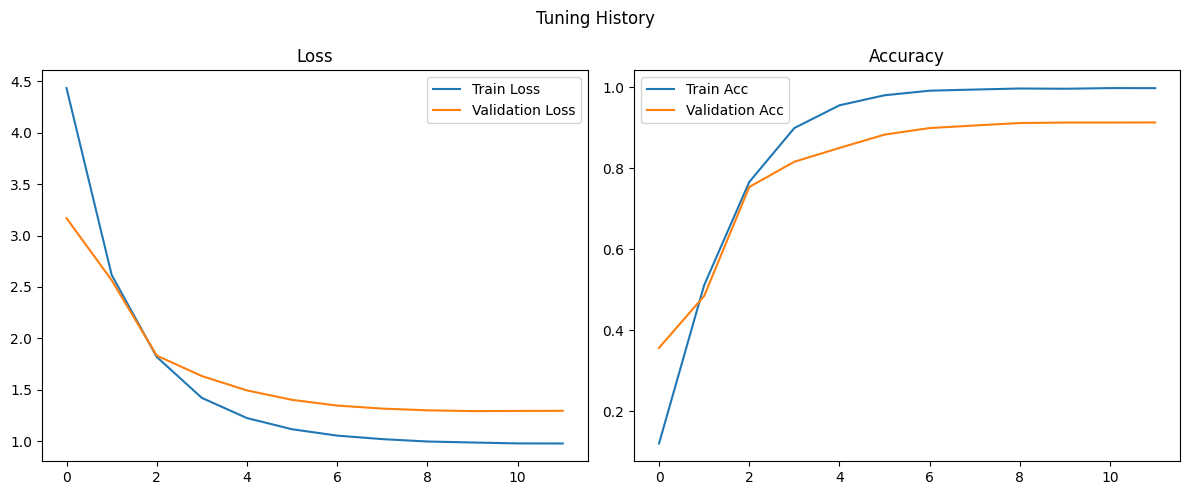

In [14]:
# Load a pretrained ResNet50
model = models.resnet50(pretrained=True)

# Replace the final classification layer
model.fc = nn.Linear(model.fc.in_features, 196)

# Set configurations
n_epochs = 12
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# All unfrozen main layers share the same starting LR for now
# We can later try varying LR per unfrozen layer with differential 10x per layer
param_groups = [
    {"params": model.fc.parameters(), "lr": 0.01},     
    {"params": model.layer4.parameters(), "lr": 0.01},
    {"params": model.layer3.parameters(), "lr": 0.01}]

# optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer = optim.SGD(param_groups, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

# Apply parallelism and move to device
if torch.cuda.device_count()>1: 
    model=nn.DataParallel(model)
model = model.to(device)

tuning_metrics1 = prog_unfreeze(model, train_loader, val_loader, n_epochs, 
                                optimizer, criterion, scheduler, stage=0)

### **Unfreeze Mid-Level Parameters (Stage 2)**

- Load the best parameter set from the previous run
- Unfreeze `layer2`
- Implement discrimative LR
- Reset the optimizer


Epoch 1/7
  Train Loss: 0.9751 | Acc: 0.9985
  Val   Loss: 1.2882 | Acc: 0.9153
  ⚡ Most Accurate Model Saved

Epoch 2/7
  Train Loss: 0.9742 | Acc: 0.9979
  Val   Loss: 1.2886 | Acc: 0.9157
  ⚡ Most Accurate Model Saved

Epoch 3/7
  Train Loss: 0.9732 | Acc: 0.9980
  Val   Loss: 1.2939 | Acc: 0.9148

Epoch 4/7
  Train Loss: 0.9728 | Acc: 0.9982
  Val   Loss: 1.2919 | Acc: 0.9148

Epoch 5/7
  Train Loss: 0.9715 | Acc: 0.9980
  Val   Loss: 1.2918 | Acc: 0.9141

Epoch 6/7
  Train Loss: 0.9716 | Acc: 0.9988
  Val   Loss: 1.2920 | Acc: 0.9139

Epoch 7/7
  Train Loss: 0.9705 | Acc: 0.9985
  Val   Loss: 1.2912 | Acc: 0.9134
  ☢️ Early Stopping Triggered

⌛ Avg. Epoch Time: 00:02:59


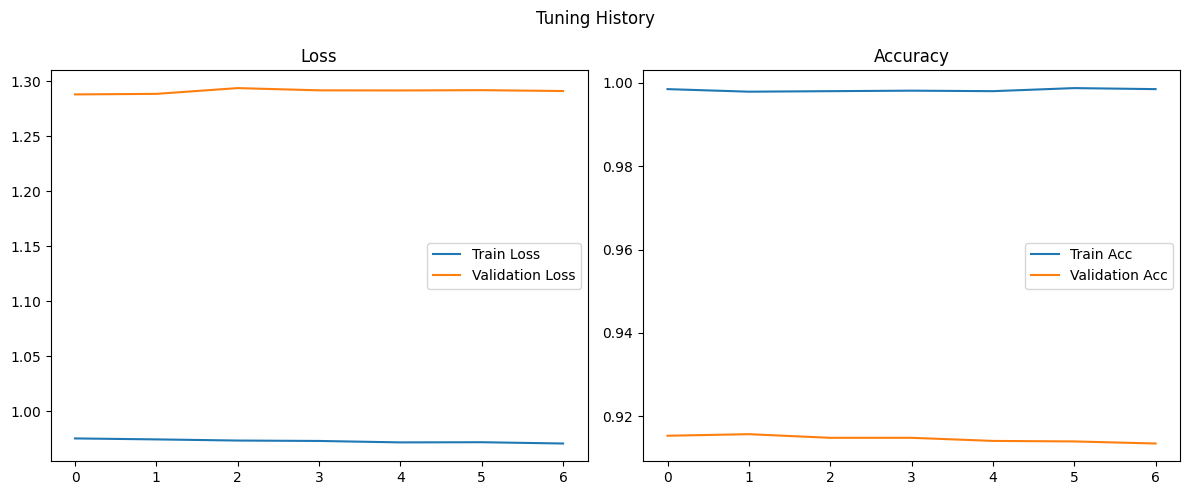

In [15]:
# Load most accurate model
model.load_state_dict(torch.load("stage0-best_params.pth")) 

# Implement discriminative LR per param group
param_groups = [
    {"params": model.module.fc.parameters(), "lr": 0.001},     
    {"params": model.module.layer4.parameters(), "lr": 2e-4},
    {"params": model.module.layer3.parameters(), "lr": 1e-4},
    {"params": model.module.layer2.parameters(), "lr": 5e-5}]

# Lower epoch on 2nd run
n_epochs = 7

# Reset optimizer and cosine annealing
# optimizer = optim.AdamW(param_groups, weight_decay=1e-4)
optimizer = optim.SGD(param_groups, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

tuning_metrics2 = prog_unfreeze(model, train_loader, val_loader, 
                                n_epochs, optimizer, criterion, 
                                scheduler, stage=1)

### **Unfreeze Early Layers (Stage 3)**

- Load the best parameter set from the previous run
- Unfreeze `layer1` and the stem block
- Reset the optimizer with the new LRs


Epoch 1/10
  Train Loss: 0.9735 | Acc: 0.9989
  Val   Loss: 1.2900 | Acc: 0.9144
  ⚡ Most Accurate Model Saved

Epoch 2/10
  Train Loss: 0.9714 | Acc: 0.9988
  Val   Loss: 1.2938 | Acc: 0.9144

Epoch 3/10
  Train Loss: 0.9719 | Acc: 0.9986
  Val   Loss: 1.2919 | Acc: 0.9138

Epoch 4/10
  Train Loss: 0.9721 | Acc: 0.9984
  Val   Loss: 1.2939 | Acc: 0.9144

Epoch 5/10
  Train Loss: 0.9707 | Acc: 0.9984
  Val   Loss: 1.2891 | Acc: 0.9148
  ⚡ Most Accurate Model Saved

Epoch 6/10
  Train Loss: 0.9715 | Acc: 0.9985
  Val   Loss: 1.2907 | Acc: 0.9152
  ⚡ Most Accurate Model Saved

Epoch 7/10
  Train Loss: 0.9716 | Acc: 0.9986
  Val   Loss: 1.2905 | Acc: 0.9167
  ⚡ Most Accurate Model Saved

Epoch 8/10
  Train Loss: 0.9717 | Acc: 0.9988
  Val   Loss: 1.2933 | Acc: 0.9147

Epoch 9/10
  Train Loss: 0.9712 | Acc: 0.9988
  Val   Loss: 1.2917 | Acc: 0.9156

Epoch 10/10
  Train Loss: 0.9726 | Acc: 0.9983
  Val   Loss: 1.2937 | Acc: 0.9147
⌛ Avg. Epoch Time: 00:02:58


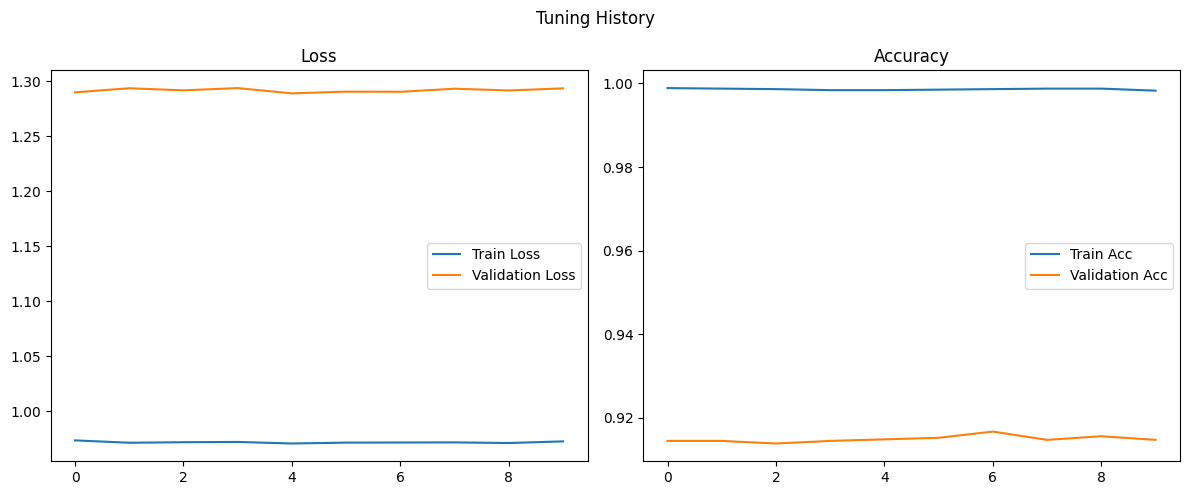

In [16]:
# Load most accurate model
model.load_state_dict(torch.load("stage1-best_params.pth"))

# Update learning rates
param_groups = [
    {"params": model.module.fc.parameters(), "lr": 1e-4},     
    {"params": model.module.layer4.parameters(), "lr": 7e-5},
    {"params": model.module.layer3.parameters(), "lr": 5e-5},
    {"params": model.module.layer2.parameters(), "lr": 2e-5},
    {"params": model.module.layer1.parameters(), "lr": 5e-6},
    {"params": model.module.conv1.parameters(), "lr": 5e-6},
    {"params": model.module.bn1.parameters(), "lr": 5e-6}]

n_epochs = 10

# Reset optimizer
# optimizer = optim.AdamW(param_groups, weight_decay=1e-4)
optimizer = optim.SGD(param_groups, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-6)

tuning_metrics3 = prog_unfreeze(model, train_loader, val_loader, 
                                n_epochs, optimizer, criterion, 
                                scheduler, stage=2) 

## **Inference on the Test Set**

The results here should match the loss and accuracy values that came from the best saved model.

In [17]:
# Load the best model from whatever stage it was produced
model.load_state_dict(torch.load("stage2-best_params.pth"))

test_data = CarImageDataset(test_paths, test_labels, LABELS_TO_IDS, get_transforms(train=False))
test_loader = DataLoader(
    test_data, 
    batch_size=32, 
    shuffle=False, 
    num_workers=2,
    pin_memory=True)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Evaluate test data 
eval_metrics = evaluate_model(model, test_loader, criterion, add_metrics=True)
loss, acc, prec, rec, f1, inf_time, y_labels, y_preds = eval_metrics
print(f"Loss: {loss:.4f} \nAccuracy: {acc:.4f} \nPrecision: {prec:.4f} \nRecall: {rec:.4f} \nF1: {f1:.4f}, \nInference Time: {inf_time}")

Loss: 1.2905 
Accuracy: 0.9167 
Precision: 0.9190 
Recall: 0.9167 
F1: 0.9164, 
Inference Time: 00:01:31


## **Analyzing the Results So Far**

In [18]:
# Display results across unfreezing stages
import pandas as pd
results_df = pd.DataFrame({
    "stage1_tr_acc": pd.Series(tuning_metrics1[1]),
    "stage1_val_acc": pd.Series(tuning_metrics1[3]),
    "stage2_tr_acc": pd.Series(tuning_metrics2[1]),
    "stage2_val_acc": pd.Series(tuning_metrics2[3]),
    "stage3_tr_acc": pd.Series(tuning_metrics3[1]),
    "stage3_val_acc": pd.Series(tuning_metrics3[3])})

results_df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater



,stage1_tr_acc,stage1_val_acc,stage2_tr_acc,stage2_val_acc,stage3_tr_acc,stage3_val_acc
0,0.120702,0.356921,0.998527,0.915309,0.998895,0.914439
1,0.511542,0.484890,0.997913,0.915682,0.998772,0.914439
2,0.766454,0.754135,0.998035,0.914812,0.998649,0.913817
3,0.899681,0.816441,0.998158,0.914812,0.998404,0.914439
4,0.955796,0.850516,0.998035,0.914065,0.998404,0.914812
5,0.980599,0.883472,0.998772,0.913941,0.998527,0.915185
6,0.991896,0.899639,0.998527,0.913444,0.998649,0.916677
7,0.994720,0.905982,NaN,NaN,0.998772,0.914687
8,0.997299,0.912076,NaN,NaN,0.998772,0.915558
9,0.996685,0.913195,NaN,NaN,0.998281,0.914687


**Based on the Metrics (The Test Set is Used to Evaluate Each Epoch):**

- The bulk of meaningful tuning happened in Stage 1, where only the `fc` and `layer4` layers are trainable
- Stages 2 and 3 oscillated and provided little contributions to the validation metrics (using the test set) that seem to be already at near peak after Stage 1
- Looking at the graphs, the model fitted the training set but still generalizes okay to the validation (test) set with accuracy gaps at a consistent ~0.08 to ~0.09
- The gap between training and test accuracies is consistent throughout Stages 2 and 3 at ~0.08 to ~0.09
- Stage 3 produced the best validation loss and accuracy at epoch 6

**Next Step:** We will try a few more experiments to see how we can further close the gap between the training and test accuracies. First, we can try to find out if there are certain photometric and geometric-based distribution shifts between train and test causing the train-test gap.